# Predicting Gravitational Anomalies in Multi-Body Systems Using PINNs

**Problem:** standard neural networks fit orbital trajectories well inside the time range they're trained on, but have no reason to respect physics once they extrapolate past it. A Physics-Informed Neural Network (PINN) adds the equations of motion as an extra loss term, so the network is penalized for predicting positions that don't satisfy Newton's law of gravitation, not just for missing the training data.

This notebook works through a 2-body system (one star, one orbiting body) as the simplest case, comparing a vanilla NN against a PINN on extrapolation.

## 1. Generating the data

I simulate a 2D orbit under gravity using Euler integration. GM=1.0, and the body starts at (1,0) with velocity (0,1), which gives a roughly circular orbit.

Euler integration isn't exact — it accumulates error over time, so the "true" orbit I'm training on already has some drift built in. That's worth keeping in mind later when I look at energy conservation.

In [ ]:
import numpy as np

def generate_orbit(GM=1.0, dt=0.01, steps=1000):
    # initial conditions
    x, y = 1.0, 0.0
    vx, vy = 0.0, 1.0

    trajectory = []

    for i in range(steps):
        t = i * dt
        r = np.sqrt(x**2+y**2)

        ax = -(GM*x)/r**3
        ay = -(GM*y)/r**3

        # store current state
        trajectory.append([t, x, y, vx, vy])

        # euler update — you fill these four lines
        x  = x+vx*dt
        y  = y+vy*dt
        vx = vx+ax*dt
        vy = vy+ay*dt

    return np.array(trajectory)

### Orbit shape

Just a sanity check that the simulated orbit looks like an orbit.

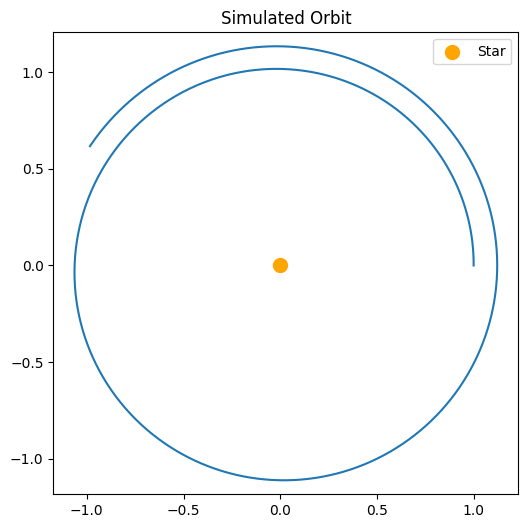

In [ ]:
import matplotlib.pyplot as plt

data = generate_orbit(GM=1.0, dt=0.01, steps=1000)

t   = data[:, 0]
x   = data[:, 1]
y   = data[:, 2]
vx  = data[:, 3]
vy  = data[:, 4]

# plot the orbit shape
plt.figure(figsize=(6,6))
plt.plot(x, y)
plt.scatter([0], [0], color='orange', s=100, label='Star')
plt.title('Simulated Orbit')
plt.axis('equal')
plt.legend()
plt.show()

### Energy conservation check

Total energy (kinetic + potential) should stay constant for a real orbit. This tells me how much drift the Euler integrator is introducing into my training data.

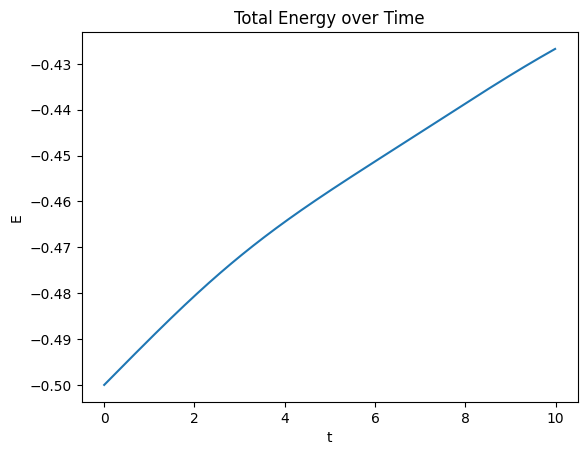

In [ ]:
# plot energy over time — should be roughly constant
KE = 0.5 * (vx**2 + vy**2)
PE = -1.0 / np.sqrt(x**2 + y**2)  # GM=1
E  = KE + PE

plt.figure()
plt.plot(t, E)
plt.title('Total Energy over Time')
plt.xlabel('t')
plt.ylabel('E')
plt.show()

## 2. Baseline: a vanilla neural network

This network takes time `t` as input and predicts `(x, y)` directly. No physics involved — it's just learning to interpolate the training trajectory. Four layers, tanh activations.

In [ ]:
import torch
import torch.nn as nn
class VanillaNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 128)
        self.layer4 = nn.Linear(128, 2)

    def forward(self, t):
        out1 = torch.tanh(self.layer1(t))
        out2 = torch.tanh(self.layer2(out1))
        out3 = torch.tanh(self.layer3(out2))
        return self.layer4(out3)

### Training the vanilla NN

Only a data loss here: mean squared error between predicted and true (x, y) at the training timestamps.

In [ ]:
# prepare data
data = generate_orbit(GM=1.0, dt=0.01, steps=1000)

t_data  = torch.tensor(data[:, 0], dtype=torch.float32).unsqueeze(1)
x_data  = torch.tensor(data[:, 1], dtype=torch.float32).unsqueeze(1)
y_data  = torch.tensor(data[:, 2], dtype=torch.float32).unsqueeze(1)

# model and optimizer
model_vanilla = VanillaNN()
optimizer     = torch.optim.Adam(model_vanilla.parameters(), lr=1e-3)

# training loop
for epoch in range(20000):
    optimizer.zero_grad()

    # data loss
    pred      = model_vanilla(t_data)
    pred_x    = pred[:, 0:1]
    pred_y    = pred[:, 1:2]
    loss_data = ((pred_x - x_data)**2 + (pred_y - y_data)**2).mean()
    loss_data.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.4f} ")

Epoch 0 | Data Loss: 1.1772 
Epoch 2000 | Data Loss: 0.0001 
Epoch 4000 | Data Loss: 0.0000 
Epoch 6000 | Data Loss: 0.0055 
Epoch 8000 | Data Loss: 0.0002 
Epoch 10000 | Data Loss: 0.0000 
Epoch 12000 | Data Loss: 0.0003 
Epoch 14000 | Data Loss: 0.0000 
Epoch 16000 | Data Loss: 0.0009 
Epoch 18000 | Data Loss: 0.0000 


## 3. The PINN

Same architecture as the vanilla NN. The difference isn't in the network itself, it's in the loss function.

In [ ]:
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 128)
        self.layer4 = nn.Linear(128, 2)

    def forward(self, t):
        out1 = torch.tanh(self.layer1(t))
        out2 = torch.tanh(self.layer2(out1))
        out3 = torch.tanh(self.layer3(out2))
        return self.layer4(out3)

### Physics loss

This is the core of the PINN. I use `torch.autograd.grad` twice to get the network's own second derivative of position with respect to time (acceleration), and compare it against what gravity says the acceleration should be (`-GMx/r³`). The residual becomes a loss term the network is trained to minimize, alongside the data loss.

tanh is used instead of ReLU because ReLU's second derivative is zero everywhere, which would kill this loss entirely.

In [ ]:
def physics_loss(model, t, GM=1.0):
    coords = model(t)
    x = coords[:, 0:1]
    y = coords[:, 1:2]
    dx_dt = torch.autograd.grad(
        x, t,
        grad_outputs=torch.ones_like(x),
        create_graph=True
    )[0]

    dy_dt = torch.autograd.grad(
        y, t,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]

    d2x_dt2 = torch.autograd.grad(
        dx_dt, t,
        grad_outputs=torch.ones_like(dx_dt),
        create_graph=True
    )[0]

    d2y_dt2 = torch.autograd.grad(
        dy_dt, t,
        grad_outputs=torch.ones_like(dy_dt),
        create_graph=True
    )[0]

    r = torch.sqrt(x**2 + y**2)

    fx = -GM * x / r**3
    fy = -GM * y / r**3

    residual_x = d2x_dt2 - fx
    residual_y = d2y_dt2 - fy

    return (residual_x**2 + residual_y**2).mean()

### Training the PINN

Total loss = data loss + 0.05 × physics loss. The collocation points (`t_phys`) go up to t=20, past the training data which only goes to t=10 this forces the network to respect the physics even where it has no data to fit.

0.05 came out of an ablation: 1.0 was unstable, 0.1 broke the orbital shape, 0.05 was stable and gave the best physics loss without hurting the data fit.

In [ ]:
# prepare data
data = generate_orbit(GM=1.0, dt=0.01, steps=1000)

t_data  = torch.tensor(data[:, 0], dtype=torch.float32).unsqueeze(1)
x_data  = torch.tensor(data[:, 1], dtype=torch.float32).unsqueeze(1)
y_data  = torch.tensor(data[:, 2], dtype=torch.float32).unsqueeze(1)

# collocation points — random time points for physics loss
t_phys = torch.linspace(0, 20, 2000).unsqueeze(1).requires_grad_(True)
# model and optimizer
model     = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(20000):
    optimizer.zero_grad()

    # data loss
    pred      = model(t_data)
    pred_x    = pred[:, 0:1]
    pred_y    = pred[:, 1:2]
    loss_data = ((pred_x - x_data)**2 + (pred_y - y_data)**2).mean()

    # physics loss
    loss_phys = physics_loss(model, t_phys)

    # total loss
    loss = loss_data + 0.01 * loss_phys

    loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch} | Data Loss: {loss_data.item():.4f} | Physics Loss: {loss_phys.item():.4f}")

Epoch 0 | Data Loss: 1.1791 | Physics Loss: 295210.7188
Epoch 2000 | Data Loss: 1.5311 | Physics Loss: 9.8528
Epoch 4000 | Data Loss: 1.2250 | Physics Loss: 9.5309
Epoch 6000 | Data Loss: 0.9544 | Physics Loss: 8.5983
Epoch 8000 | Data Loss: 0.6335 | Physics Loss: 6.3987
Epoch 10000 | Data Loss: 0.4506 | Physics Loss: 5.7822
Epoch 12000 | Data Loss: 0.2075 | Physics Loss: 2.5835
Epoch 14000 | Data Loss: 0.0813 | Physics Loss: 0.5605
Epoch 16000 | Data Loss: 0.0055 | Physics Loss: 0.1717
Epoch 18000 | Data Loss: 0.0010 | Physics Loss: 0.0924


## 4. Results: training range vs extrapolation

Both models should look fine inside the training range (t: 0-10). The real test is t: 10-20, which the PINN has never seen actual data for, only physics constraints.

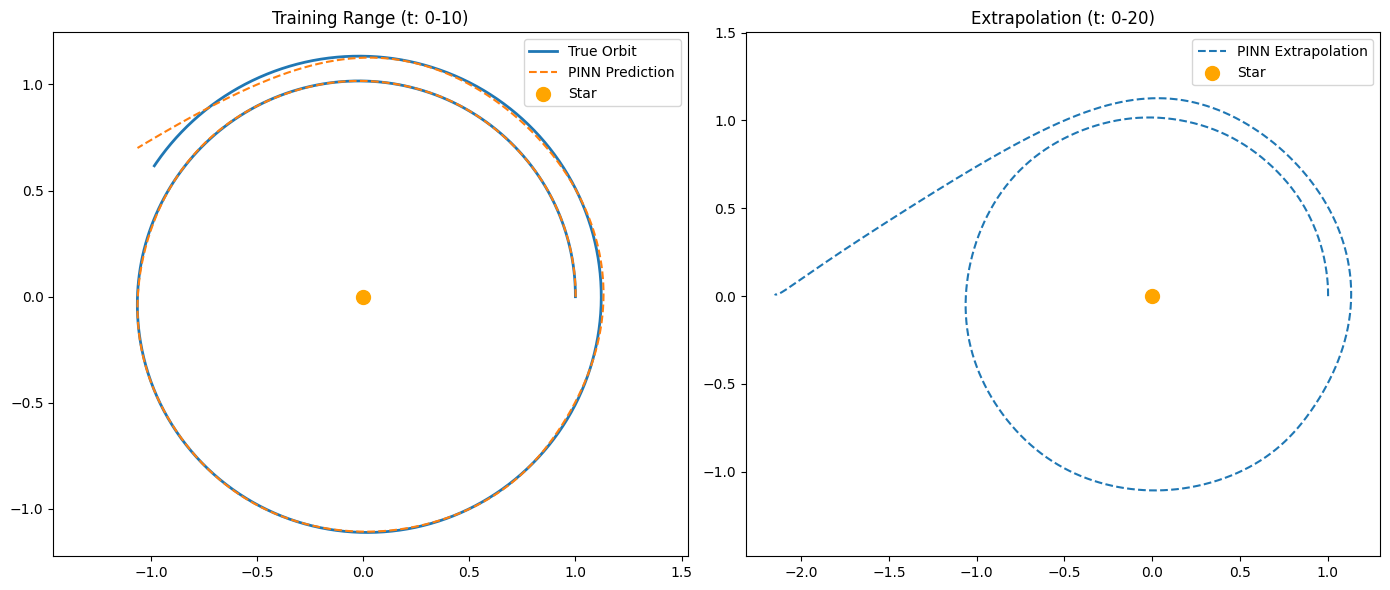

In [ ]:
model.eval()

# predict on training range
t_test = torch.linspace(0, 10, 1000).unsqueeze(1)
with torch.no_grad():
    pred = model(t_test).numpy()

# predict beyond training range
t_extrap = torch.linspace(0, 20, 2000).unsqueeze(1)
with torch.no_grad():
    pred_extrap = model(t_extrap).numpy()

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# training range
axes[0].plot(data[:, 1], data[:, 2], label='True Orbit', linewidth=2)
axes[0].plot(pred[:, 0], pred[:, 1], '--', label='PINN Prediction')
axes[0].scatter([0], [0], color='orange', s=100, label='Star')
axes[0].set_title('Training Range (t: 0-10)')
axes[0].legend()
axes[0].axis('equal')

# extrapolation
axes[1].plot(pred_extrap[:, 0], pred_extrap[:, 1], '--', label='PINN Extrapolation')
axes[1].scatter([0], [0], color='orange', s=100, label='Star')
axes[1].set_title('Extrapolation (t: 0-20)')
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.show()

### Energy conservation for the PINN

Velocity here is estimated with finite differences (`np.gradient`) on predicted positions, since the model doesn't output velocity directly — so this energy curve is an approximation, not exact.

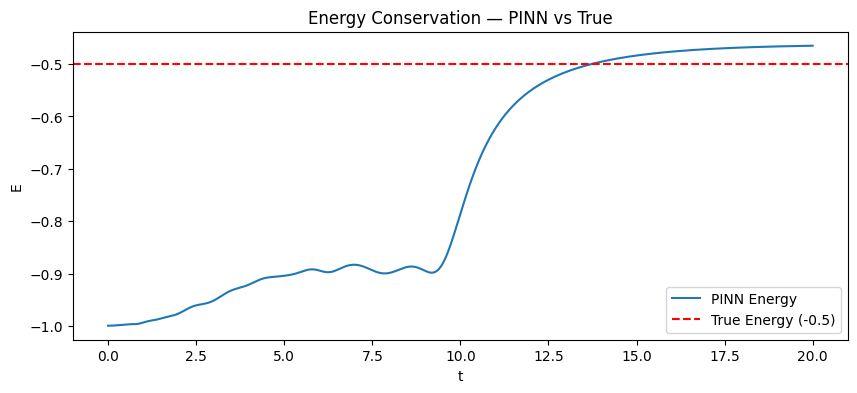

In [ ]:
model.eval()
t_test = torch.linspace(0, 20, 2000).unsqueeze(1)
with torch.no_grad():
    pred = model(t_test).numpy()

pred_x  = pred[:, 0]
pred_y  = pred[:, 1]

# approximate velocity via finite differences
pred_vx = np.gradient(pred_x)
pred_vy = np.gradient(pred_y)

KE   = 0.5 * (pred_vx**2 + pred_vy**2)
PE   = -1.0 / np.sqrt(pred_x**2 + pred_y**2)
E    = KE + PE

plt.figure(figsize=(10, 4))
plt.plot(t_test.numpy(), E, label='PINN Energy')
plt.axhline(y=-0.5, color='red', linestyle='--', label='True Energy (-0.5)')
plt.title('Energy Conservation — PINN vs True')
plt.xlabel('t')
plt.ylabel('E')
plt.legend()
plt.show()

## 5. PINN vs vanilla NN, side by side

Same extrapolation window, same energy calculation, both models plotted together.

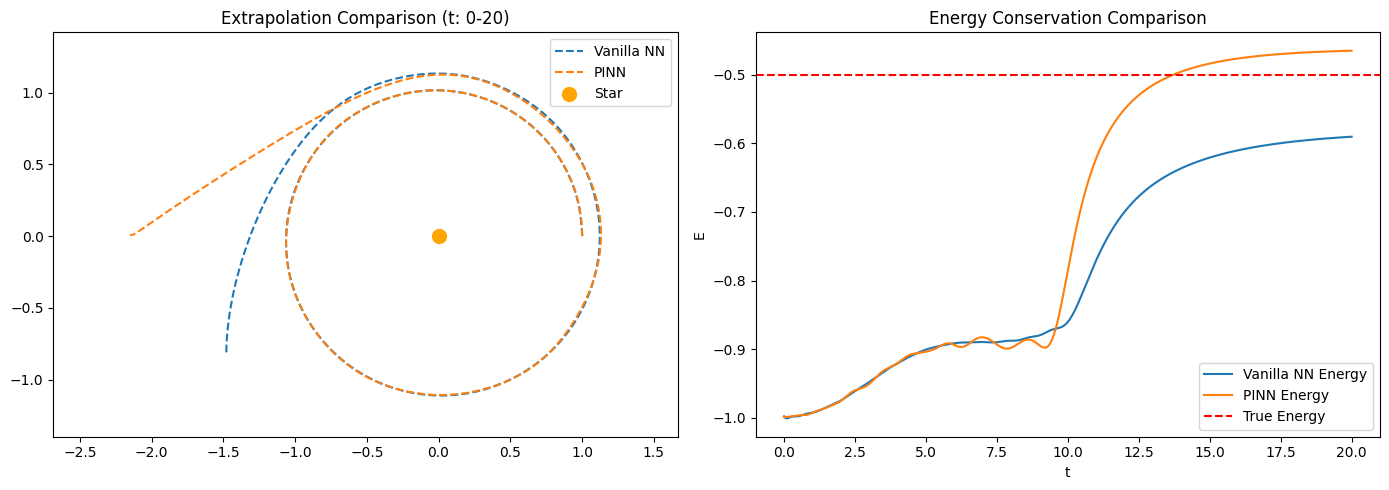

In [ ]:
# predictions
t_extrap = torch.linspace(0, 20, 2000).unsqueeze(1)

with torch.no_grad():
    pred_vanilla = model_vanilla(t_extrap).numpy()



# energy for vanilla
vx_v = np.gradient(pred_vanilla[:, 0])
vy_v = np.gradient(pred_vanilla[:, 1])
KE_v = 0.5 * (vx_v**2 + vy_v**2)
PE_v = -1.0 / np.sqrt(pred_vanilla[:, 0]**2 + pred_vanilla[:, 1]**2)
E_v  = KE_v + PE_v

# energy for PINN
vx_p = np.gradient(pred_extrap[:, 0])
vy_p = np.gradient(pred_extrap[:, 1])
KE_p = 0.5 * (vx_p**2 + vy_p**2)
PE_p = -1.0 / np.sqrt(pred_extrap[:, 0]**2 + pred_extrap[:, 1]**2)
E_p  = KE_p + PE_p

t_np = t_extrap.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# orbit comparison
axes[0].plot(pred_vanilla[:, 0], pred_vanilla[:, 1], label='Vanilla NN', linestyle='--')
axes[0].plot(pred_extrap[:, 0], pred_extrap[:, 1], label='PINN', linestyle='--')
axes[0].scatter([0], [0], color='orange', s=100, label='Star')
axes[0].set_title('Extrapolation Comparison (t: 0-20)')
axes[0].legend()
axes[0].axis('equal')

# energy comparison
axes[1].plot(t_np, E_v, label='Vanilla NN Energy')
axes[1].plot(t_np, E_p, label='PINN Energy')
axes[1].axhline(y=-0.5, color='red', linestyle='--', label='True Energy')
axes[1].set_title('Energy Conservation Comparison')
axes[1].set_xlabel('t')
axes[1].set_ylabel('E')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Quantitative comparison

Visual comparison only goes so far, so here's the actual MSE on the unseen range (t: 10-20) for both models.

In [ ]:
data_extrap = generate_orbit(GM=1.0, dt=0.01, steps=2000)
true_x = data_extrap[1000:, 1]
true_y = data_extrap[1000:, 2]

t_unseen = torch.linspace(10, 20, 1000).unsqueeze(1)

with torch.no_grad():
    pred_pinn         = model(t_unseen).numpy()
    pred_vanilla       = model_vanilla(t_unseen).numpy()       # for MSE, t=10-20 only
    pred_vanilla_full  = model_vanilla(t_extrap).numpy()        # for export, t=0-20

mse_pinn    = np.mean((pred_pinn[:, 0] - true_x[:1000])**2 +
                      (pred_pinn[:, 1] - true_y[:1000])**2)
mse_vanilla = np.mean((pred_vanilla[:, 0] - true_x[:1000])**2 +
                      (pred_vanilla[:, 1] - true_y[:1000])**2)

print(f"PINN extrapolation MSE:    {mse_pinn:.4f}")
print(f"Vanilla extrapolation MSE: {mse_vanilla:.4f}")

PINN extrapolation MSE:    5.0726
Vanilla extrapolation MSE: 3.7796


## Conclusion

The PINN doesn't beat the vanilla NN on extrapolation MSE — both come out close, since a 2-body orbit is simple enough that even a plain network can pick up the periodic pattern from data alone. Where the PINN does help is visually: it holds the orbital shape better past t=10, even though the numbers don't show a clear edge yet.

This 2-body case is really just a proof of concept before the interesting version, where physics constraints matter more, is the 3-body system, since a vanilla network has no way to fake gravitational interactions between three bodies it hasn't seen data for.

In [ ]:
import json
json.dump({
    "t": t_extrap.squeeze().tolist(),
    "ground_truth": {"x": data_extrap[:,1].tolist(), "y": data_extrap[:,2].tolist()},
    "vanilla_pred": {"x": pred_vanilla_full[:,0].tolist(), "y": pred_vanilla_full[:,1].tolist()},
    "pinn_pred": {"x": pred_extrap[:,0].tolist(), "y": pred_extrap[:,1].tolist()}
}, open("trajectories.json", "w"))